In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

DATA_DIR = "pipeline_output_final"
META_FILE = f"{DATA_DIR}/final_metadata.csv"

class ExoplanetData:
    def __init__(self, data_dir="pipeline_output_final"):
        self.data_dir = data_dir
        self.meta = pd.read_csv(os.path.join(data_dir, "final_metadata.csv"))
    
    def get_batch(self, batch_size=32):
        """Returns random (X, y) batch for training."""
        sample = self.meta.sample(n=batch_size)
        X, y = [], []
        
        # Group by file to minimize disk reads
        for filename, group in sample.groupby('filename'):
            path = os.path.join(self.data_dir, filename)
            with np.load(path) as data:
                indices = group['index_in_batch'].values
                X.append(data['flux_local'][indices]) # Change to flux_global if needed
                y.extend(group['label'].values)
                
        return np.concatenate(X), np.array(y)

inspecting KIC 9570741 (Label: 1)
  - Source File: batch_3.npz
  - Index in File: 10
  - Period: 15.77955 days
  - SNR: 43.6


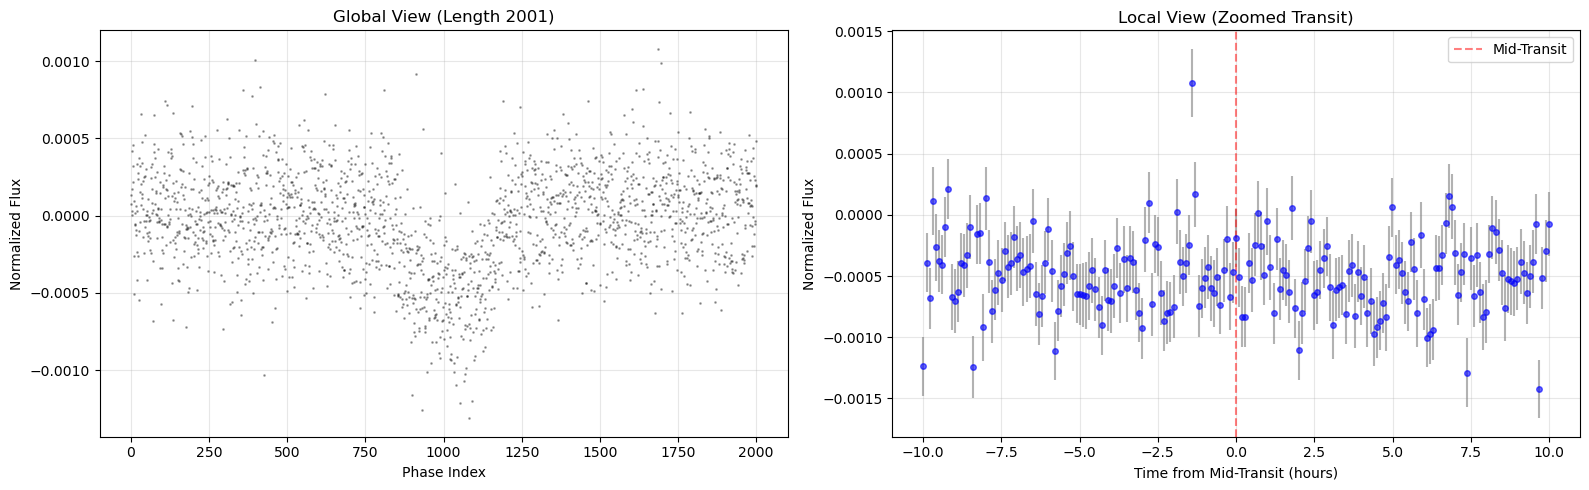

In [3]:
def visualize_random_star():
    # 1. Load the Master Index
    if not os.path.exists(META_FILE):
        print("Metadata file not found. Did you run the merge step?")
        return

    meta = pd.read_csv(META_FILE)
    
    # 2. Pick a random "Confirmed Planet" (Label 1) to make it interesting
    planets = meta[meta['label'] == 1]
    if len(planets) == 0:
        print("No planets found in metadata! Picking a random star instead.")
        row = meta.sample(1).iloc[0]
    else:
        row = planets.sample(1).iloc[0]

    print(f"inspecting KIC {row['kic']} (Label: {row['label']})")
    print(f"  - Source File: {row['filename']}")
    print(f"  - Index in File: {row['index_in_batch']}")
    print(f"  - Period: {row['period']} days")
    print(f"  - SNR: {row['snr']}")

    # 3. Load the specific batch file
    file_path = os.path.join(DATA_DIR, row['filename'])
    try:
        with np.load(file_path) as data:
            idx = int(row['index_in_batch'])
            
            # Extract Views
            flux_global = data['flux_global'][idx]
            flux_local  = data['flux_local'][idx]
            error_local = data['error_local'][idx]
            time_local  = data['time_local'][idx]
            
    except Exception as e:
        print(f"Error reading file: {e}")
        return

    # 4. Plotting
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

    # --- LEFT: GLOBAL VIEW (What the CNN sees for context) ---
    # This is phase-folded (0.0 to 1.0 or -0.5 to 0.5)
    ax1.plot(flux_global, '.', color='black', alpha=0.3, markersize=2)
    ax1.set_title(f"Global View (Length {len(flux_global)})")
    ax1.set_xlabel("Phase Index")
    ax1.set_ylabel("Normalized Flux")
    ax1.grid(True, alpha=0.3)

    # --- RIGHT: LOCAL VIEW (The Transit) ---
    # This is the zoomed-in dip with error bars
    ax2.errorbar(time_local, flux_local, yerr=error_local, 
                 fmt='o', color='blue', ecolor='gray', alpha=0.6, markersize=4)
    ax2.set_title(f"Local View (Zoomed Transit)")
    ax2.set_xlabel("Time from Mid-Transit (hours)")
    ax2.set_ylabel("Normalized Flux")
    ax2.axvline(0, color='red', linestyle='--', alpha=0.5, label="Mid-Transit")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    visualize_random_star()